In [4]:
from pathlib import Path
import zipfile
import pandas as pd

project_dir = Path("ucsd_triton_transit_evening_gap")

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
output_dir = project_dir / "outputs"

for folder in [raw_dir, processed_dir, output_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("项目文件夹创建完成")
print(project_dir)

项目文件夹创建完成
ucsd_triton_transit_evening_gap


In [5]:
zip_path = raw_dir / "tritontransit-ca-us.zip"
extract_dir = raw_dir / "current_gtfs"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("GTFS 文件解压完成，包含以下文件：")

for file in sorted(extract_dir.iterdir()):
    print("-", file.name)

FileNotFoundError: [Errno 2] No such file or directory: 'ucsd_triton_transit_evening_gap\\data\\raw\\tritontransit-ca-us.zip'

In [4]:
gtfs_path = raw_dir / "current_gtfs"

def read_gtfs_table(file_name):
    file_path = gtfs_path / file_name
    
    if file_path.exists():
        df = pd.read_csv(file_path)
        print(f"{file_name} 读取成功：{df.shape[0]} 行，{df.shape[1]} 列")
        return df
    else:
        print(f"{file_name} 不存在")
        return pd.DataFrame()

agency = read_gtfs_table("agency.txt")
routes = read_gtfs_table("routes.txt")
trips = read_gtfs_table("trips.txt")
stop_times = read_gtfs_table("stop_times.txt")
stops = read_gtfs_table("stops.txt")
calendar = read_gtfs_table("calendar.txt")
calendar_dates = read_gtfs_table("calendar_dates.txt")
feed_info = read_gtfs_table("feed_info.txt")

agency.txt 读取成功：1 行，8 列
routes.txt 读取成功：6 行，12 列
trips.txt 读取成功：501 行，9 列
stop_times.txt 读取成功：7126 行，12 列
stops.txt 读取成功：60 行，12 列
calendar.txt 读取成功：4 行，10 列
calendar_dates.txt 读取成功：2 行，3 列
feed_info.txt 读取成功：1 行，8 列


In [5]:
tables = {
    "agency": agency,
    "routes": routes,
    "trips": trips,
    "stop_times": stop_times,
    "stops": stops,
    "calendar": calendar,
    "calendar_dates": calendar_dates,
    "feed_info": feed_info
}

summary = []

for table_name, df in tables.items():
    summary.append({
        "表名": table_name,
        "行数": len(df),
        "列数": len(df.columns),
        "是否为空": df.empty
    })

data_quality_summary = pd.DataFrame(summary)

display(data_quality_summary)

data_quality_summary.to_csv(
    output_dir / "data_quality_summary.csv",
    index=False
)

,表名,行数,列数,是否为空
0,agency,1,8,False
1,routes,6,12,False
2,trips,501,9,False
3,stop_times,7126,12,False
4,stops,60,12,False
5,calendar,4,10,False
6,calendar_dates,2,3,False
7,feed_info,1,8,False


In [6]:
import numpy as np

# 把 GTFS 时间转成分钟数，比如 17:30:00 -> 1050
def gtfs_time_to_minutes(t):
    if pd.isna(t):
        return np.nan
    
    try:
        h, m, s = str(t).split(":")
        return int(h) * 60 + int(m) + int(s) / 60
    except:
        return np.nan

# 把分钟数转回 HH:MM 格式，方便展示
def minutes_to_hhmm(x):
    if pd.isna(x):
        return None
    
    x = int(x)
    h = x // 60
    m = x % 60
    return f"{h:02d}:{m:02d}"

stop_times["arrival_min"] = stop_times["arrival_time"].apply(gtfs_time_to_minutes)
stop_times["departure_min"] = stop_times["departure_time"].apply(gtfs_time_to_minutes)

# 每个 trip 的开始时间、结束时间
trip_time_summary = (
    stop_times
    .dropna(subset=["arrival_min"])
    .groupby("trip_id")
    .agg(
        trip_start_min=("arrival_min", "min"),
        trip_end_min=("arrival_min", "max"),
        timepoint_count=("arrival_min", "count")
    )
    .reset_index()
)

trip_time_summary["trip_start_time"] = trip_time_summary["trip_start_min"].apply(minutes_to_hhmm)
trip_time_summary["trip_end_time"] = trip_time_summary["trip_end_min"].apply(minutes_to_hhmm)
trip_time_summary["trip_start_hour"] = (trip_time_summary["trip_start_min"] // 60).astype(int)
trip_time_summary["trip_end_hour"] = (trip_time_summary["trip_end_min"] // 60).astype(int)

display(trip_time_summary.head())
print("trip_time_summary 行数：", len(trip_time_summary))

,trip_id,trip_start_min,trip_end_min,timepoint_count,trip_start_time,trip_end_time,trip_start_hour,trip_end_hour
0,GC_SatSunSB_T01,600.0,655.0,4,10:00,10:55,10,10
1,GC_SatSunSB_T02,630.0,685.0,4,10:30,11:25,10,11
2,GC_SatSunSB_T03,660.0,715.0,4,11:00,11:55,11,11
3,GC_SatSunSB_T04,690.0,745.0,4,11:30,12:25,11,12
4,GC_SatSunSB_T05,720.0,775.0,4,12:00,12:55,12,12


trip_time_summary 行数： 501


In [7]:
route_cols = [
    "route_id",
    "route_short_name",
    "route_long_name",
    "route_desc"
]

trip_summary = (
    trips
    .merge(trip_time_summary, on="trip_id", how="left")
    .merge(routes[route_cols], on="route_id", how="left")
)

trip_summary["route_short_name"] = trip_summary["route_short_name"].fillna("").astype(str)
trip_summary["route_long_name"] = trip_summary["route_long_name"].fillna("").astype(str)

trip_summary["route_name"] = (
    trip_summary["route_short_name"] + " - " + trip_summary["route_long_name"]
)

# 标记是否是晚间班次：17:00–21:59，也就是 17:00–22:00 之前
trip_summary["is_evening_trip"] = trip_summary["trip_start_hour"].between(17, 21)

display(trip_summary.head())

print("trip_summary 行数：", len(trip_summary))
print("路线数量：", trip_summary["route_name"].nunique())
print("service_id 分布：")
display(trip_summary["service_id"].value_counts())

,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed,trip_start_min,...,timepoint_count,trip_start_time,trip_end_time,trip_start_hour,trip_end_hour,route_short_name,route_long_name,route_desc,route_name,is_evening_trip
0,1010,Weekday,REG_Weekday_T01,Regents Express,1,Reg_2,Regents_Express_shape,1,1,420.0,...,3,07:00,07:15,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False
1,1010,Weekday,REG_Weekday_T02,Regents Express,1,Reg_1,Regents_Express_shape,1,1,430.0,...,3,07:10,07:25,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False
2,1010,Weekday,REG_Weekday_T03,Regents Express,1,Reg_2,Regents_Express_shape,1,1,440.0,...,3,07:20,07:35,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False
3,1010,Weekday,REG_Weekday_T04,Regents Express,1,Reg_1,Regents_Express_shape,1,1,450.0,...,3,07:30,07:45,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False
4,1010,Weekday,REG_Weekday_T05,Regents Express,1,Reg_2,Regents_Express_shape,1,1,460.0,...,3,07:40,07:55,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False


trip_summary 行数： 501
路线数量： 6
service_id 分布：


service_id
Weekday         328
SatSun           63
Weekday_SpBk     63
SatSun_SpBk      47
Name: count, dtype: int64

In [8]:
weekday_trips = trip_summary[trip_summary["service_id"] == "Weekday"].copy()

display(weekday_trips.head())

print("正常工作日 trip 数量：", len(weekday_trips))
print("正常工作日路线分布：")
display(
    weekday_trips["route_name"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "route_name", "route_name": "trip_count"})
)

,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed,trip_start_min,...,timepoint_count,trip_start_time,trip_end_time,trip_start_hour,trip_end_hour,route_short_name,route_long_name,route_desc,route_name,is_evening_trip
0,1010,Weekday,REG_Weekday_T01,Regents Express,1,Reg_2,Regents_Express_shape,1,1,420.0,...,3,07:00,07:15,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False
1,1010,Weekday,REG_Weekday_T02,Regents Express,1,Reg_1,Regents_Express_shape,1,1,430.0,...,3,07:10,07:25,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False
2,1010,Weekday,REG_Weekday_T03,Regents Express,1,Reg_2,Regents_Express_shape,1,1,440.0,...,3,07:20,07:35,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False
3,1010,Weekday,REG_Weekday_T04,Regents Express,1,Reg_1,Regents_Express_shape,1,1,450.0,...,3,07:30,07:45,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False
4,1010,Weekday,REG_Weekday_T05,Regents Express,1,Reg_2,Regents_Express_shape,1,1,460.0,...,3,07:40,07:55,7,7,R,Regents Express,Connects the East Campus commuter parking lots...,R - Regents Express,False


正常工作日 trip 数量： 328
正常工作日路线分布：


,trip_count,count
0,R - Regents Express,81
1,ML - Mesa Loop,80
2,IL - Inside Loop,59
3,OL - Outside Loop,55
4,S - SIO Shuttle,53


In [9]:
hourly_service = (
    weekday_trips
    .groupby("trip_start_hour")
    .agg(
        hourly_service_frequency=("trip_id", "nunique")
    )
    .reset_index()
    .sort_values("trip_start_hour")
)

hourly_service["estimated_headway_min"] = 60 / hourly_service["hourly_service_frequency"]
hourly_service["is_evening_hour"] = hourly_service["trip_start_hour"].between(17, 21)

display(hourly_service)

hourly_service.to_csv(
    output_dir / "hourly_service_frequency_weekday.csv",
    index=False
)

,trip_start_hour,hourly_service_frequency,estimated_headway_min,is_evening_hour
0,7,24,2.500000,False
1,8,24,2.500000,False
2,9,24,2.500000,False
3,10,24,2.500000,False
4,11,24,2.500000,False
5,12,24,2.500000,False
6,13,24,2.500000,False
7,14,24,2.500000,False
8,15,24,2.500000,False
9,16,24,2.500000,False


In [10]:
evening_hourly_service = hourly_service[hourly_service["is_evening_hour"] == True].copy()

display(evening_hourly_service)

print("晚间总班次数：", evening_hourly_service["hourly_service_frequency"].sum())
print("晚间平均每小时班次数：", round(evening_hourly_service["hourly_service_frequency"].mean(), 2))
print("晚间平均估算发车间隔：", round(evening_hourly_service["estimated_headway_min"].mean(), 2), "分钟")

,trip_start_hour,hourly_service_frequency,estimated_headway_min,is_evening_hour
10,17,24,2.500000,True
11,18,23,2.608696,True
12,19,17,3.529412,True
13,20,13,4.615385,True
14,21,10,6.000000,True


晚间总班次数： 87
晚间平均每小时班次数： 17.4
晚间平均估算发车间隔： 3.85 分钟


In [11]:
route_service_summary = (
    weekday_trips
    .groupby(["route_id", "route_name"])
    .agg(
        total_trips=("trip_id", "nunique"),
        evening_trips=("is_evening_trip", "sum"),
        first_trip_min=("trip_start_min", "min"),
        last_trip_min=("trip_start_min", "max")
    )
    .reset_index()
)

route_service_summary["evening_service_share"] = (
    route_service_summary["evening_trips"] / route_service_summary["total_trips"]
)

route_service_summary["estimated_evening_headway_min"] = np.where(
    route_service_summary["evening_trips"] > 0,
    5 * 60 / route_service_summary["evening_trips"],
    np.nan
)

route_service_summary["first_trip_time"] = route_service_summary["first_trip_min"].apply(minutes_to_hhmm)
route_service_summary["last_trip_time"] = route_service_summary["last_trip_min"].apply(minutes_to_hhmm)

route_service_summary["service_span_hours"] = (
    route_service_summary["last_trip_min"] - route_service_summary["first_trip_min"]
) / 60

route_service_summary = route_service_summary.sort_values(
    "estimated_evening_headway_min",
    ascending=False
)

display(route_service_summary)

route_service_summary.to_csv(
    output_dir / "route_service_summary_weekday.csv",
    index=False
)

,route_id,route_name,total_trips,evening_trips,first_trip_min,last_trip_min,evening_service_share,estimated_evening_headway_min,first_trip_time,last_trip_time,service_span_hours
1,1020,S - SIO Shuttle,53,13,420.0,1230.0,0.245283,23.076923,07:00,20:30,13.500000
2,1030,OL - Outside Loop,55,15,420.0,1290.0,0.272727,20.000000,07:00,21:30,14.500000
3,1040,IL - Inside Loop,59,19,420.0,1305.0,0.322034,15.789474,07:00,21:45,14.750000
0,1010,R - Regents Express,81,20,420.0,1330.0,0.246914,15.000000,07:00,22:10,15.166667
4,1050,ML - Mesa Loop,80,20,420.0,1290.0,0.250000,15.000000,07:00,21:30,14.500000


In [12]:
route_hourly_service = (
    weekday_trips
    .groupby(["route_id", "route_name", "trip_start_hour"])
    .agg(
        hourly_trips=("trip_id", "nunique")
    )
    .reset_index()
)

route_hourly_service["estimated_headway_min"] = 60 / route_hourly_service["hourly_trips"]
route_hourly_service["is_evening_hour"] = route_hourly_service["trip_start_hour"].between(17, 21)

route_evening_hourly_service = route_hourly_service[
    route_hourly_service["is_evening_hour"] == True
].copy()

display(route_evening_hourly_service.sort_values(
    ["trip_start_hour", "hourly_trips"]
))

route_evening_hourly_service.to_csv(
    output_dir / "route_evening_hourly_service_weekday.csv",
    index=False
)

,route_id,route_name,trip_start_hour,hourly_trips,estimated_headway_min,is_evening_hour
26,1020,S - SIO Shuttle,17,4,15.0,True
40,1030,OL - Outside Loop,17,4,15.0,True
55,1040,IL - Inside Loop,17,4,15.0,True
10,1010,R - Regents Express,17,6,10.0,True
70,1050,ML - Mesa Loop,17,6,10.0,True
27,1020,S - SIO Shuttle,18,4,15.0,True
41,1030,OL - Outside Loop,18,4,15.0,True
56,1040,IL - Inside Loop,18,4,15.0,True
11,1010,R - Regents Express,18,5,12.0,True
71,1050,ML - Mesa Loop,18,6,10.0,True


In [14]:
# 复制一份 stop_times
stop_times_clean = stop_times.copy()

# 确保已经有 arrival_min
stop_times_clean["arrival_min"] = stop_times_clean["arrival_time"].apply(gtfs_time_to_minutes)

# 按 trip 和 stop_sequence 排序
stop_times_clean = stop_times_clean.sort_values(["trip_id", "stop_sequence"]).copy()

# 对每个 trip 内部的缺失 arrival_min 做线性插值
stop_times_clean["estimated_stop_min"] = (
    stop_times_clean
    .groupby("trip_id")["arrival_min"]
    .transform(lambda x: x.interpolate(method="linear", limit_direction="both"))
)

# 转成小时
stop_times_clean["estimated_stop_hour"] = (
    stop_times_clean["estimated_stop_min"] // 60
).astype("Int64")

# 标记晚间站点访问，17:00–21:59
stop_times_clean["is_evening_stop_visit"] = (
    stop_times_clean["estimated_stop_hour"].between(17, 21)
)

display(stop_times_clean.head(15))

print("原始 arrival_time 缺失数量：", stop_times_clean["arrival_time"].isna().sum())
print("插值后 estimated_stop_min 缺失数量：", stop_times_clean["estimated_stop_min"].isna().sum())

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,continuous_pickup,continuous_drop_off,shape_dist_traveled,timepoint,arrival_min,departure_min,estimated_stop_min,estimated_stop_hour,is_evening_stop_visit
6078,GC_SatSunSB_T01,10:00:00,10:00:00,10772,1,NaN,NaN,NaN,NaN,NaN,NaN,1,600.0,600.0,600.000000,10,False
6079,GC_SatSunSB_T01,NaN,NaN,4005,2,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,604.285714,10,False
6080,GC_SatSunSB_T01,NaN,NaN,4006,3,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,608.571429,10,False
6081,GC_SatSunSB_T01,NaN,NaN,99447,4,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,612.857143,10,False
6082,GC_SatSunSB_T01,NaN,NaN,13002,5,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,617.142857,10,False
6083,GC_SatSunSB_T01,NaN,NaN,12788,6,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,621.428571,10,False
6084,GC_SatSunSB_T01,NaN,NaN,11255,7,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,625.714286,10,False
6085,GC_SatSunSB_T01,10:30:00,10:30:00,11247,8,NaN,NaN,NaN,NaN,NaN,NaN,1,630.0,630.0,630.000000,10,False
6086,GC_SatSunSB_T01,NaN,NaN,9917,9,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,636.666667,10,False
6087,GC_SatSunSB_T01,NaN,NaN,9918,10,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,643.333333,10,False


原始 arrival_time 缺失数量： 5593
插值后 estimated_stop_min 缺失数量： 0


In [15]:
stop_master = (
    stop_times_clean
    .merge(trips, on="trip_id", how="left")
    .merge(
        routes[["route_id", "route_short_name", "route_long_name", "route_desc"]],
        on="route_id",
        how="left"
    )
    .merge(
        stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]],
        on="stop_id",
        how="left"
    )
)

stop_master["route_name"] = (
    stop_master["route_short_name"].fillna("").astype(str)
    + " - "
    + stop_master["route_long_name"].fillna("").astype(str)
)

weekday_stop_master = stop_master[stop_master["service_id"] == "Weekday"].copy()

display(weekday_stop_master.head())

print("weekday_stop_master 行数：", len(weekday_stop_master))
print("涉及站点数：", weekday_stop_master["stop_id"].nunique())
print("涉及路线数：", weekday_stop_master["route_name"].nunique())

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,continuous_pickup,continuous_drop_off,...,shape_id,wheelchair_accessible,bikes_allowed,route_short_name,route_long_name,route_desc,stop_name,stop_lat,stop_lon,route_name
1554,IL_Weekday_T01,07:00:00,07:00:00,88986,1,NaN,NaN,NaN,NaN,NaN,...,Inside_Loop_shape,1,1,IL,Inside Loop,Circles the central campus in a clockwise dire...,UCSD Central Campus Trolley,32.879300,-117.231916,IL - Inside Loop
1555,IL_Weekday_T01,NaN,NaN,9906,2,NaN,NaN,NaN,NaN,NaN,...,Inside_Loop_shape,1,1,IL,Inside Loop,Circles the central campus in a clockwise dire...,Warren Field (South),32.880989,-117.229831,IL - Inside Loop
1556,IL_Weekday_T01,NaN,NaN,9903,3,NaN,NaN,NaN,NaN,NaN,...,Inside_Loop_shape,1,1,IL,Inside Loop,Circles the central campus in a clockwise dire...,Gilman Dr & Pepper Canyon Dr (North),32.876343,-117.230416,IL - Inside Loop
1557,IL_Weekday_T01,NaN,NaN,10772,4,NaN,NaN,NaN,NaN,NaN,...,Inside_Loop_shape,1,1,IL,Inside Loop,Circles the central campus in a clockwise dire...,Gilman Transit Center (North),32.877111,-117.237377,IL - Inside Loop
1558,IL_Weekday_T01,NaN,NaN,9908,5,NaN,NaN,NaN,NaN,NaN,...,Inside_Loop_shape,1,1,IL,Inside Loop,Circles the central campus in a clockwise dire...,WongAvery Library (West),32.874272,-117.238416,IL - Inside Loop


weekday_stop_master 行数： 4387
涉及站点数： 52
涉及路线数： 5


In [16]:
stop_service_summary = (
    weekday_stop_master
    .groupby(["stop_id", "stop_name", "stop_lat", "stop_lon"])
    .agg(
        total_visits=("trip_id", "count"),
        evening_visits=("is_evening_stop_visit", "sum"),
        routes_serving_stop=("route_name", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
)

stop_service_summary["evening_coverage_rate"] = (
    stop_service_summary["evening_visits"] / stop_service_summary["total_visits"]
)

# 只关注全天访问量较高的站点，避免小站点干扰
high_visit_threshold = stop_service_summary["total_visits"].quantile(0.75)

priority_stop_summary = (
    stop_service_summary[stop_service_summary["total_visits"] >= high_visit_threshold]
    .sort_values(["evening_coverage_rate", "total_visits"], ascending=[True, False])
    .copy()
)

display(priority_stop_summary.head(15))

stop_service_summary.to_csv(
    output_dir / "stop_service_summary_weekday.csv",
    index=False
)

priority_stop_summary.to_csv(
    output_dir / "priority_stop_summary_weekday.csv",
    index=False
)

,stop_id,stop_name,stop_lat,stop_lon,total_visits,evening_visits,routes_serving_stop,evening_coverage_rate
38,9919,P703 / Regents Parking Lots,32.879802,-117.220002,162,40,R - Regents Express,0.246914
31,9912,Mesa Nueva,32.875787,-117.223533,160,42,ML - Mesa Loop,0.2625
30,9911,Warren Field (North),32.880735,-117.230701,136,36,"OL - Outside Loop, R - Regents Express",0.264706
47,11902,Gilman Transit Center (South),32.876952,-117.234952,161,43,"OL - Outside Loop, S - SIO Shuttle",0.267081
26,9904,WongAvery Library (East),32.874461,-117.238340,108,30,"OL - Outside Loop, S - SIO Shuttle",0.277778
49,24150,Eighth College / Theatre District (South),32.872084,-117.241795,108,30,"OL - Outside Loop, S - SIO Shuttle",0.277778
27,9906,Warren Field (South),32.880989,-117.229831,140,39,"IL - Inside Loop, R - Regents Express",0.278571
25,9903,Gilman Dr & Pepper Canyon Dr (North),32.876343,-117.230416,139,39,"IL - Inside Loop, ML - Mesa Loop",0.280576
29,9910,Revelle College (East),32.875574,-117.243091,112,32,"IL - Inside Loop, S - SIO Shuttle",0.285714
50,24151,Eighth College / Theatre District (North),32.871718,-117.242206,112,32,"IL - Inside Loop, S - SIO Shuttle",0.285714


In [17]:
route_gap = route_service_summary.copy()

def min_max_score(series):
    if series.max() == series.min():
        return pd.Series(0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

# 1. 班次间隔得分：晚间发车间隔越长，缺口越大
route_gap["headway_score"] = min_max_score(
    route_gap["estimated_evening_headway_min"]
)

# 2. 末班车偏早得分：目标是至少服务到 22:00
target_last_trip_min = 22 * 60

route_gap["early_last_trip_score"] = (
    (target_last_trip_min - route_gap["last_trip_min"]) / 120
).clip(lower=0, upper=1)

# 3. 晚间服务占比低得分：晚间占比越低，缺口越大
route_gap["low_evening_share_score"] = 1 - min_max_score(
    route_gap["evening_service_share"]
)

# 4. 综合得分
route_gap["evening_gap_score"] = (
    0.40 * route_gap["headway_score"]
    + 0.35 * route_gap["early_last_trip_score"]
    + 0.25 * route_gap["low_evening_share_score"]
)

route_gap = route_gap.sort_values("evening_gap_score", ascending=False)

display(
    route_gap[
        [
            "route_name",
            "total_trips",
            "evening_trips",
            "estimated_evening_headway_min",
            "last_trip_time",
            "evening_service_share",
            "headway_score",
            "early_last_trip_score",
            "low_evening_share_score",
            "evening_gap_score"
        ]
    ]
)

route_gap.to_csv(
    output_dir / "route_evening_gap_score_weekday.csv",
    index=False
)

,route_name,total_trips,evening_trips,estimated_evening_headway_min,last_trip_time,evening_service_share,headway_score,early_last_trip_score,low_evening_share_score,evening_gap_score
1,S - SIO Shuttle,53,13,23.076923,20:30,0.245283,1.000000,0.750,1.000000,0.912500
2,OL - Outside Loop,55,15,20.000000,21:30,0.272727,0.619048,0.250,0.642424,0.495725
4,ML - Mesa Loop,80,20,15.000000,21:30,0.250000,0.000000,0.250,0.938542,0.322135
0,R - Regents Express,81,20,15.000000,22:10,0.246914,0.000000,0.000,0.978755,0.244689
3,IL - Inside Loop,59,19,15.789474,21:45,0.322034,0.097744,0.125,0.000000,0.082848


In [18]:
def assign_priority(score):
    if score >= 0.70:
        return "P1 - high priority"
    elif score >= 0.40:
        return "P2 - medium priority"
    else:
        return "P3 - low priority"

route_gap["optimization_priority"] = route_gap["evening_gap_score"].apply(assign_priority)

display(
    route_gap[
        [
            "route_name",
            "evening_gap_score",
            "optimization_priority",
            "estimated_evening_headway_min",
            "last_trip_time",
            "evening_trips"
        ]
    ]
)

route_gap.to_csv(
    output_dir / "route_optimization_priority_weekday.csv",
    index=False
)

,route_name,evening_gap_score,optimization_priority,estimated_evening_headway_min,last_trip_time,evening_trips
1,S - SIO Shuttle,0.912500,P1 - high priority,23.076923,20:30,13
2,OL - Outside Loop,0.495725,P2 - medium priority,20.000000,21:30,15
4,ML - Mesa Loop,0.322135,P3 - low priority,15.000000,21:30,20
0,R - Regents Express,0.244689,P3 - low priority,15.000000,22:10,20
3,IL - Inside Loop,0.082848,P3 - low priority,15.789474,21:45,19


In [19]:
# 晚间小时服务缺口排序
evening_hour_gap = evening_hourly_service.copy()

evening_hour_gap["hour_range"] = (
    evening_hour_gap["trip_start_hour"].astype(str).str.zfill(2)
    + ":00-"
    + (evening_hour_gap["trip_start_hour"] + 1).astype(str).str.zfill(2)
    + ":00"
)

evening_hour_gap = evening_hour_gap.sort_values(
    "hourly_service_frequency",
    ascending=True
)

display(evening_hour_gap[
    [
        "hour_range",
        "hourly_service_frequency",
        "estimated_headway_min"
    ]
])

evening_hour_gap.to_csv(
    output_dir / "evening_hour_gap_ranking.csv",
    index=False
)

,hour_range,hourly_service_frequency,estimated_headway_min
14,21:00-22:00,10,6.000000
13,20:00-21:00,13,4.615385
12,19:00-20:00,17,3.529412
11,18:00-19:00,23,2.608696
10,17:00-18:00,24,2.500000


In [20]:
def make_route_recommendation(row):
    if row["evening_gap_score"] >= 0.70:
        return "优先优化：增加晚间班次，并延后末班车"
    elif row["early_last_trip_score"] >= 0.25 and row["headway_score"] >= 0.50:
        return "重点优化：补充晚间班次，适当延后末班车"
    elif row["early_last_trip_score"] >= 0.25:
        return "适度优化：优先考虑延后末班车"
    elif row["headway_score"] >= 0.50:
        return "适度优化：提高晚间发车频率"
    else:
        return "保持监控：当前晚间服务缺口相对较低"

route_recommendation = route_gap.copy()

route_recommendation["recommended_action"] = route_recommendation.apply(
    make_route_recommendation,
    axis=1
)

display(
    route_recommendation[
        [
            "route_name",
            "optimization_priority",
            "evening_gap_score",
            "evening_trips",
            "estimated_evening_headway_min",
            "last_trip_time",
            "evening_service_share",
            "recommended_action"
        ]
    ]
)

route_recommendation.to_csv(
    output_dir / "route_recommendation_weekday.csv",
    index=False
)

,route_name,optimization_priority,evening_gap_score,evening_trips,estimated_evening_headway_min,last_trip_time,evening_service_share,recommended_action
1,S - SIO Shuttle,P1 - high priority,0.912500,13,23.076923,20:30,0.245283,优先优化：增加晚间班次，并延后末班车
2,OL - Outside Loop,P2 - medium priority,0.495725,15,20.000000,21:30,0.272727,重点优化：补充晚间班次，适当延后末班车
4,ML - Mesa Loop,P3 - low priority,0.322135,20,15.000000,21:30,0.250000,适度优化：优先考虑延后末班车
0,R - Regents Express,P3 - low priority,0.244689,20,15.000000,22:10,0.246914,保持监控：当前晚间服务缺口相对较低
3,IL - Inside Loop,P3 - low priority,0.082848,19,15.789474,21:45,0.322034,保持监控：当前晚间服务缺口相对较低


In [21]:
stop_gap = stop_service_summary.copy()

def min_max_score(series):
    if series.max() == series.min():
        return pd.Series(0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

# 1. 站点访问量越高，越重要
stop_gap["visit_importance_score"] = min_max_score(stop_gap["total_visits"])

# 2. 晚间覆盖率越低，缺口越大
stop_gap["low_evening_coverage_score"] = 1 - min_max_score(
    stop_gap["evening_coverage_rate"]
)

# 3. 标记重点站点：宿舍、停车场、Trolley、图书馆、学院、交通枢纽等
key_stop_keywords = [
    "Trolley",
    "Parking",
    "Mesa",
    "Gilman",
    "Library",
    "College",
    "Revelle",
    "Warren",
    "Eighth",
    "Ridge Walk",
    "Pepper Canyon",
    "Transit Center"
]

pattern = "|".join(key_stop_keywords)

stop_gap["key_stop_flag"] = stop_gap["stop_name"].str.contains(
    pattern,
    case=False,
    na=False
)

stop_gap["key_stop_score"] = stop_gap["key_stop_flag"].astype(int)

# 4. 综合站点缺口评分
stop_gap["stop_gap_score"] = (
    0.45 * stop_gap["visit_importance_score"]
    + 0.35 * stop_gap["low_evening_coverage_score"]
    + 0.20 * stop_gap["key_stop_score"]
)

stop_gap = stop_gap.sort_values("stop_gap_score", ascending=False)

display(
    stop_gap[
        [
            "stop_name",
            "total_visits",
            "evening_visits",
            "evening_coverage_rate",
            "key_stop_flag",
            "routes_serving_stop",
            "stop_gap_score"
        ]
    ].head(15)
)

stop_gap.to_csv(
    output_dir / "stop_evening_gap_score_weekday.csv",
    index=False
)

,stop_name,total_visits,evening_visits,evening_coverage_rate,key_stop_flag,routes_serving_stop,stop_gap_score
51,UCSD Central Campus Trolley,309,89,0.288026,True,"IL - Inside Loop, OL - Outside Loop, R - Regen...",0.805084
38,P703 / Regents Parking Lots,162,40,0.246914,True,R - Regents Express,0.734166
31,Mesa Nueva,160,42,0.2625,True,ML - Mesa Loop,0.659573
47,Gilman Transit Center (South),161,43,0.267081,True,"OL - Outside Loop, S - SIO Shuttle",0.640442
30,Warren Field (North),136,36,0.264706,True,"OL - Outside Loop, R - Regents Express",0.607326
22,Athena Parking Structure,81,20,0.246914,True,R - Regents Express,0.591783
39,UCSD Health La Jolla Trolley (South),81,20,0.246914,True,R - Regents Express,0.591783
33,P785 Parking Lot,81,20,0.246914,True,R - Regents Express,0.591783
23,UCSD Health La Jolla Trolley (North),81,20,0.246914,True,R - Regents Express,0.591783
27,Warren Field (South),140,39,0.278571,True,"IL - Inside Loop, R - Regents Express",0.551128


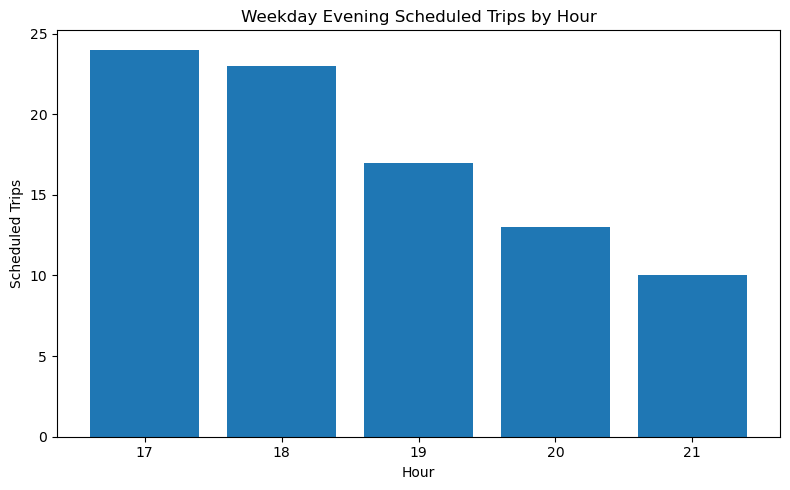

In [22]:
import matplotlib.pyplot as plt

# 图 1：晚间小时服务频率
plt.figure(figsize=(8, 5))
plt.bar(
    evening_hourly_service["trip_start_hour"].astype(str),
    evening_hourly_service["hourly_service_frequency"]
)
plt.xlabel("Hour")
plt.ylabel("Scheduled Trips")
plt.title("Weekday Evening Scheduled Trips by Hour")
plt.tight_layout()
plt.savefig(output_dir / "chart_evening_hourly_service.png", dpi=200)
plt.show()

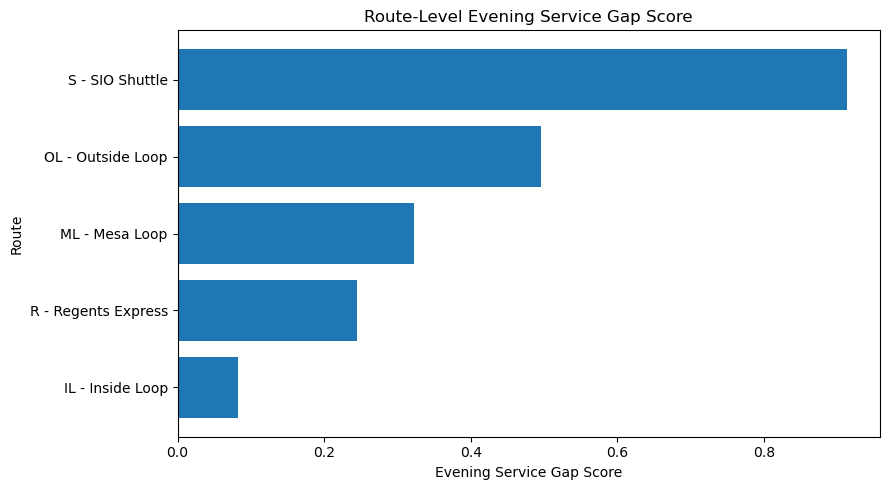

In [23]:
# 图 2：路线 Evening Gap Score
route_plot = route_gap.sort_values("evening_gap_score", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(
    route_plot["route_name"],
    route_plot["evening_gap_score"]
)
plt.xlabel("Evening Service Gap Score")
plt.ylabel("Route")
plt.title("Route-Level Evening Service Gap Score")
plt.tight_layout()
plt.savefig(output_dir / "chart_route_gap_score.png", dpi=200)
plt.show()

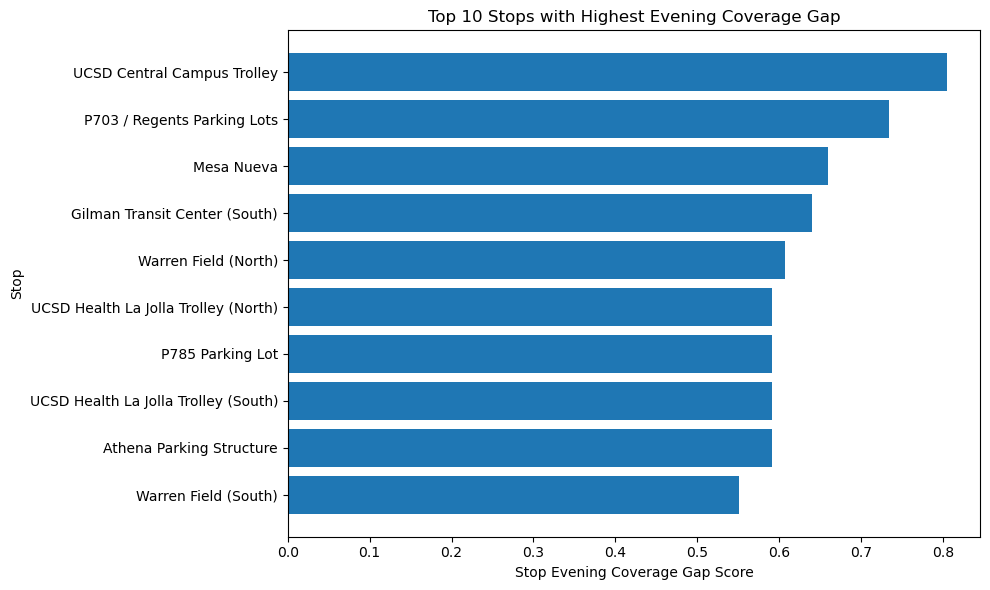

In [24]:
# 图 3：站点 Gap Score Top 10
top_stop_plot = stop_gap.head(10).sort_values("stop_gap_score", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top_stop_plot["stop_name"],
    top_stop_plot["stop_gap_score"]
)
plt.xlabel("Stop Evening Coverage Gap Score")
plt.ylabel("Stop")
plt.title("Top 10 Stops with Highest Evening Coverage Gap")
plt.tight_layout()
plt.savefig(output_dir / "chart_stop_gap_score_top10.png", dpi=200)
plt.show()

In [25]:
import math

simulation = route_gap.copy()

target_evening_headway = 20
evening_window_minutes = 5 * 60
target_last_trip_min = 22 * 60

def recommend_added_trips(row):
    current_evening_trips = row["evening_trips"]
    
    # P1：补到目标 headway
    if row["optimization_priority"] == "P1 - high priority":
        required_trips = math.ceil(evening_window_minutes / target_evening_headway)
        added = max(required_trips - current_evening_trips, 0)
        
        # 如果末班明显早，也至少补 1 班
        if row["last_trip_min"] < target_last_trip_min and added == 0:
            added = 1
            
        return added
    
    # P2：如果末班早于 22:00，补 1 班
    elif row["optimization_priority"] == "P2 - medium priority":
        if row["last_trip_min"] < target_last_trip_min:
            return 1
        else:
            return 0
    
    # P3：不调整
    else:
        return 0

simulation["recommended_added_evening_trips"] = simulation.apply(
    recommend_added_trips,
    axis=1
)

simulation["evening_trips_after"] = (
    simulation["evening_trips"]
    + simulation["recommended_added_evening_trips"]
)

simulation["estimated_evening_headway_after"] = (
    evening_window_minutes / simulation["evening_trips_after"]
)

simulation["last_trip_min_after"] = simulation["last_trip_min"]

simulation.loc[
    (simulation["recommended_added_evening_trips"] > 0)
    & (simulation["last_trip_min"] < target_last_trip_min),
    "last_trip_min_after"
] = target_last_trip_min

simulation["last_trip_time_after"] = simulation["last_trip_min_after"].apply(minutes_to_hhmm)

display(
    simulation[
        [
            "route_name",
            "optimization_priority",
            "evening_trips",
            "recommended_added_evening_trips",
            "evening_trips_after",
            "estimated_evening_headway_min",
            "estimated_evening_headway_after",
            "last_trip_time",
            "last_trip_time_after"
        ]
    ]
)

simulation.to_csv(
    output_dir / "route_optimization_simulation.csv",
    index=False
)

,route_name,optimization_priority,evening_trips,recommended_added_evening_trips,evening_trips_after,estimated_evening_headway_min,estimated_evening_headway_after,last_trip_time,last_trip_time_after
1,S - SIO Shuttle,P1 - high priority,13,2,15,23.076923,20.000000,20:30,22:00
2,OL - Outside Loop,P2 - medium priority,15,1,16,20.000000,18.750000,21:30,22:00
4,ML - Mesa Loop,P3 - low priority,20,0,20,15.000000,15.000000,21:30,21:30
0,R - Regents Express,P3 - low priority,20,0,20,15.000000,15.000000,22:10,22:10
3,IL - Inside Loop,P3 - low priority,19,0,19,15.789474,15.789474,21:45,21:45


In [26]:
before_after_summary = pd.DataFrame({
    "metric": [
        "Total evening trips",
        "Average route evening headway",
        "Routes ending before 22:00",
        "High priority routes"
    ],
    "before": [
        simulation["evening_trips"].sum(),
        simulation["estimated_evening_headway_min"].mean(),
        (simulation["last_trip_min"] < target_last_trip_min).sum(),
        (simulation["optimization_priority"] == "P1 - high priority").sum()
    ],
    "after": [
        simulation["evening_trips_after"].sum(),
        simulation["estimated_evening_headway_after"].mean(),
        (simulation["last_trip_min_after"] < target_last_trip_min).sum(),
        0
    ]
})

before_after_summary["improvement"] = (
    before_after_summary["before"] - before_after_summary["after"]
)

display(before_after_summary)

before_after_summary.to_csv(
    output_dir / "optimization_before_after_summary.csv",
    index=False
)

,metric,before,after,improvement
0,Total evening trips,87.000000,90.000000,-3.000000
1,Average route evening headway,17.773279,16.907895,0.865385
2,Routes ending before 22:00,4.000000,2.000000,2.000000
3,High priority routes,1.000000,0.000000,1.000000


In [27]:
worst_hour = evening_hour_gap.iloc[0]
top_route = route_gap.iloc[0]
top_stop = stop_gap.iloc[0]

summary_text = f"""
项目第一版业务结论：

1. 晚间服务缺口主要集中在 {worst_hour['hour_range']}。
该小时段计划班次数为 {int(worst_hour['hourly_service_frequency'])} 班，
是 17:00-22:00 晚间窗口中服务供给最低的时段。

2. 路线层面，{top_route['route_name']} 的晚间服务缺口评分最高。
该路线晚间计划班次数为 {int(top_route['evening_trips'])} 班，
估算晚间发车间隔约为 {round(top_route['estimated_evening_headway_min'], 1)} 分钟，
末班车时间为 {top_route['last_trip_time']}。

3. 站点层面，{top_stop['stop_name']} 的晚间覆盖缺口评分最高。
该站点全天访问次数为 {int(top_stop['total_visits'])} 次，
晚间访问次数为 {int(top_stop['evening_visits'])} 次，
晚间覆盖率为 {round(top_stop['evening_coverage_rate'] * 100, 1)}%。

4. 初步优化方案是：
优先对 P1 路线增加晚间班次并延后末班车；
对 P2 路线重点考虑补充 1 个晚间班次；
对高访问但晚间覆盖率偏低的站点进行重点覆盖补强。
"""

print(summary_text)

with open(output_dir / "first_business_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)


项目第一版业务结论：

1. 晚间服务缺口主要集中在 21:00-22:00。
该小时段计划班次数为 10 班，
是 17:00-22:00 晚间窗口中服务供给最低的时段。

2. 路线层面，S - SIO Shuttle 的晚间服务缺口评分最高。
该路线晚间计划班次数为 13 班，
估算晚间发车间隔约为 23.1 分钟，
末班车时间为 20:30。

3. 站点层面，UCSD Central Campus Trolley 的晚间覆盖缺口评分最高。
该站点全天访问次数为 309 次，
晚间访问次数为 89 次，
晚间覆盖率为 28.8%。

4. 初步优化方案是：
优先对 P1 路线增加晚间班次并延后末班车；
对 P2 路线重点考虑补充 1 个晚间班次；
对高访问但晚间覆盖率偏低的站点进行重点覆盖补强。



In [28]:
from pathlib import Path

expected_files = [
    "data_quality_summary.csv",
    "hourly_service_frequency_weekday.csv",
    "route_service_summary_weekday.csv",
    "route_evening_gap_score_weekday.csv",
    "route_recommendation_weekday.csv",
    "stop_evening_gap_score_weekday.csv",
    "route_optimization_simulation.csv",
    "optimization_before_after_summary.csv",
    "first_business_summary.txt",
    "chart_evening_hourly_service.png",
    "chart_route_gap_score.png",
    "chart_stop_gap_score_top10.png"
]

file_check = []

for file in expected_files:
    file_path = output_dir / file
    file_check.append({
        "file_name": file,
        "exists": file_path.exists()
    })

file_check_df = pd.DataFrame(file_check)
display(file_check_df)

,file_name,exists
0,data_quality_summary.csv,True
1,hourly_service_frequency_weekday.csv,True
2,route_service_summary_weekday.csv,True
3,route_evening_gap_score_weekday.csv,True
4,route_recommendation_weekday.csv,True
5,stop_evening_gap_score_weekday.csv,True
6,route_optimization_simulation.csv,True
7,optimization_before_after_summary.csv,True
8,first_business_summary.txt,True
9,chart_evening_hourly_service.png,True


In [29]:
dashboard_dir = project_dir / "dashboard_data"
dashboard_dir.mkdir(parents=True, exist_ok=True)

# 1. 晚间小时服务缺口表
dashboard_hourly = evening_hour_gap.copy()
dashboard_hourly.to_csv(
    dashboard_dir / "dashboard_hourly_evening_gap.csv",
    index=False
)

# 2. 路线优化优先级表
dashboard_route = route_recommendation[
    [
        "route_name",
        "optimization_priority",
        "evening_gap_score",
        "evening_trips",
        "estimated_evening_headway_min",
        "last_trip_time",
        "evening_service_share",
        "recommended_action"
    ]
].copy()

dashboard_route.to_csv(
    dashboard_dir / "dashboard_route_priority.csv",
    index=False
)

# 3. 站点覆盖缺口 Top 表
dashboard_stop = stop_gap[
    [
        "stop_name",
        "total_visits",
        "evening_visits",
        "evening_coverage_rate",
        "key_stop_flag",
        "routes_serving_stop",
        "stop_gap_score",
        "stop_lat",
        "stop_lon"
    ]
].copy()

dashboard_stop.to_csv(
    dashboard_dir / "dashboard_stop_gap.csv",
    index=False
)

# 4. 优化模拟表
dashboard_simulation = simulation[
    [
        "route_name",
        "optimization_priority",
        "evening_trips",
        "recommended_added_evening_trips",
        "evening_trips_after",
        "estimated_evening_headway_min",
        "estimated_evening_headway_after",
        "last_trip_time",
        "last_trip_time_after"
    ]
].copy()

dashboard_simulation.to_csv(
    dashboard_dir / "dashboard_optimization_simulation.csv",
    index=False
)

print("Dashboard 数据表已生成：")
for file in dashboard_dir.iterdir():
    print("-", file.name)

Dashboard 数据表已生成：
- dashboard_hourly_evening_gap.csv
- dashboard_optimization_simulation.csv
- dashboard_route_priority.csv
- dashboard_stop_gap.csv


In [30]:
route_hour_pivot = (
    route_evening_hourly_service
    .pivot_table(
        index="route_name",
        columns="trip_start_hour",
        values="hourly_trips",
        aggfunc="sum",
        fill_value=0
    )
)

display(route_hour_pivot)

route_hour_pivot.to_csv(
    dashboard_dir / "dashboard_route_hour_heatmap.csv"
)

trip_start_hour,17,18,19,20,21
route_name,,,,,
IL - Inside Loop,4,4,4,4,3
ML - Mesa Loop,6,6,4,2,2
OL - Outside Loop,4,4,3,2,2
R - Regents Express,6,5,3,3,3
S - SIO Shuttle,4,4,3,2,0


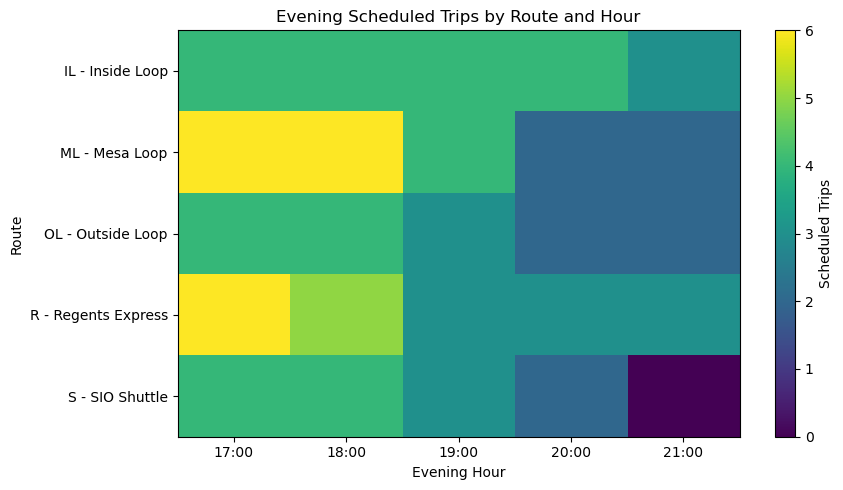

In [31]:
plt.figure(figsize=(9, 5))
plt.imshow(route_hour_pivot, aspect="auto")

plt.xticks(
    range(len(route_hour_pivot.columns)),
    [str(int(h)) + ":00" for h in route_hour_pivot.columns]
)

plt.yticks(
    range(len(route_hour_pivot.index)),
    route_hour_pivot.index
)

plt.xlabel("Evening Hour")
plt.ylabel("Route")
plt.title("Evening Scheduled Trips by Route and Hour")

plt.colorbar(label="Scheduled Trips")
plt.tight_layout()

plt.savefig(output_dir / "chart_route_hour_heatmap.png", dpi=200)
plt.show()

In [32]:
before_total_evening_trips = simulation["evening_trips"].sum()
after_total_evening_trips = simulation["evening_trips_after"].sum()

before_avg_headway = simulation["estimated_evening_headway_min"].mean()
after_avg_headway = simulation["estimated_evening_headway_after"].mean()

before_early_routes = (simulation["last_trip_min"] < target_last_trip_min).sum()
after_early_routes = (simulation["last_trip_min_after"] < target_last_trip_min).sum()

before_p1_routes = (simulation["optimization_priority"] == "P1 - high priority").sum()
after_p1_routes = 0

optimization_summary_clean = pd.DataFrame({
    "metric": [
        "Total evening scheduled trips",
        "Average route-level evening headway",
        "Routes ending before 22:00",
        "High-priority gap routes"
    ],
    "before": [
        before_total_evening_trips,
        round(before_avg_headway, 2),
        before_early_routes,
        before_p1_routes
    ],
    "after": [
        after_total_evening_trips,
        round(after_avg_headway, 2),
        after_early_routes,
        after_p1_routes
    ],
    "business_interpretation": [
        "晚间计划班次数增加，服务供给增强",
        "路线平均晚间发车间隔缩短",
        "末班车偏早的路线减少",
        "高优先级服务缺口路线被处理"
    ]
})

display(optimization_summary_clean)

optimization_summary_clean.to_csv(
    output_dir / "optimization_summary_clean.csv",
    index=False
)

,metric,before,after,business_interpretation
0,Total evening scheduled trips,87.00,90.00,晚间计划班次数增加，服务供给增强
1,Average route-level evening headway,17.77,16.91,路线平均晚间发车间隔缩短
2,Routes ending before 22:00,4.00,2.00,末班车偏早的路线减少
3,High-priority gap routes,1.00,0.00,高优先级服务缺口路线被处理


In [33]:
data_dictionary_text = """
# Data Dictionary

## Project Dataset

This project uses the latest UCSD Triton Transit GTFS static feed. GTFS is a public transit data format that contains route, trip, stop, and schedule information.

## Raw GTFS Tables

### agency.txt
Transit agency information.

Important fields:
- `agency_id`: agency identifier
- `agency_name`: transit agency name
- `agency_url`: agency website
- `agency_timezone`: agency timezone

### routes.txt
Route-level information.

Important fields:
- `route_id`: route identifier
- `route_short_name`: short route name
- `route_long_name`: full route name
- `route_desc`: route description
- `route_type`: type of transit route

### trips.txt
Trip-level information.

Important fields:
- `route_id`: route identifier
- `service_id`: service calendar identifier
- `trip_id`: trip identifier
- `trip_headsign`: trip destination or direction
- `direction_id`: direction of travel

### stop_times.txt
Stop sequence and scheduled arrival/departure information for each trip.

Important fields:
- `trip_id`: trip identifier
- `arrival_time`: scheduled arrival time
- `departure_time`: scheduled departure time
- `stop_id`: stop identifier
- `stop_sequence`: stop order within a trip

### stops.txt
Stop-level information.

Important fields:
- `stop_id`: stop identifier
- `stop_name`: stop name
- `stop_lat`: stop latitude
- `stop_lon`: stop longitude

### calendar.txt
Regular service calendar.

Important fields:
- `service_id`: service calendar identifier
- `monday` to `sunday`: service availability by weekday
- `start_date`: service start date
- `end_date`: service end date

### calendar_dates.txt
Special service date exceptions.

Important fields:
- `service_id`: service calendar identifier
- `date`: exception date
- `exception_type`: added or removed service

## Processed Tables

### gtfs_service_master.csv
Joined stop-level GTFS table created from `stop_times`, `trips`, `routes`, and `stops`.

### hourly_service_frequency_weekday.csv
Hourly scheduled trip counts for normal weekday service.

### route_service_summary_weekday.csv
Route-level service summary, including total trips, evening trips, evening service share, first trip time, last trip time, and service span.

### route_evening_gap_score_weekday.csv
Route-level Evening Service Gap Score table.

### stop_evening_gap_score_weekday.csv
Stop-level evening coverage gap score table.

### route_optimization_simulation.csv
Simulated schedule optimization table comparing current evening service and recommended adjusted service.

## Key Metrics

### hourly_service_frequency
Number of scheduled trips starting in each hour.

### estimated_headway_min
Estimated average headway in minutes. It is calculated as:

`60 / hourly_service_frequency`

For route-level evening analysis, it is calculated as:

`300 / evening_trips`

because the evening window is 17:00-22:00, or 5 hours.

### evening_service_share
Share of a route's total weekday trips that occur during the evening window.

### last_trip_time
The last scheduled trip start time for a route.

### service_span_hours
Difference between first scheduled trip and last scheduled trip.

### stop_evening_coverage_rate
Share of a stop's total weekday visits that occur during the evening window.

### Evening Service Gap Score
A composite route-level score used to prioritize schedule optimization.

It combines:
- headway score
- early last trip score
- low evening service share score

Higher score means higher evening service gap.
"""

with open(project_dir / "data_dictionary.md", "w", encoding="utf-8") as f:
    f.write(data_dictionary_text)

print("data_dictionary.md 已生成")

data_dictionary.md 已生成


In [34]:
top_hour = evening_hour_gap.iloc[0]
top_route = route_gap.iloc[0]
top_stop = stop_gap.iloc[0]

readme_text = f"""
# UCSD Triton Transit Evening Service Gap Diagnosis & Schedule Optimization

## Project Overview

This project analyzes the latest UCSD Triton Transit GTFS static feed to diagnose evening scheduled service gaps and propose schedule optimization recommendations.

The business problem is not whether the service exists. The goal is to identify where evening service gaps are concentrated across time periods, routes, and stops, then prioritize operational improvements.

## Business Question

Where are the main evening scheduled service gaps in UCSD Triton Transit, and how should service be optimized under limited operating resources?

Specifically, this project answers:

1. Which evening hours have the lowest scheduled service supply?
2. Which routes have the highest evening service gap?
3. Which stops have high total service but low evening coverage?
4. Which routes and time periods should be prioritized for schedule optimization?

## Data Source

- UCSD Triton Transit latest GTFS static feed
- GTFS tables used: `routes.txt`, `trips.txt`, `stop_times.txt`, `stops.txt`, `calendar.txt`, `calendar_dates.txt`

## Methodology

The analysis follows a business analytics workflow:

1. Validate GTFS data quality
2. Build trip-level and stop-level service tables
3. Calculate weekday evening service metrics
4. Diagnose service gaps by hour, route, and stop
5. Design an Evening Service Gap Score
6. Simulate schedule optimization scenarios
7. Generate operational recommendations

## Key Metrics

- Hourly scheduled trip frequency
- Estimated headway
- Evening service share
- Last trip time
- Route service span
- Stop evening coverage rate
- Evening Service Gap Score

## Key Findings

### 1. Evening service weakens after 20:00

The lowest scheduled service hour is **{top_hour['hour_range']}**, with **{int(top_hour['hourly_service_frequency'])} scheduled trips**.

### 2. Highest route-level service gap

The route with the highest Evening Service Gap Score is:

**{top_route['route_name']}**

This route has:
- Evening trips: {int(top_route['evening_trips'])}
- Estimated evening headway: {round(top_route['estimated_evening_headway_min'], 1)} minutes
- Last trip time: {top_route['last_trip_time']}

### 3. Highest stop-level evening coverage gap

The stop with the highest stop-level evening coverage gap score is:

**{top_stop['stop_name']}**

This stop has:
- Total weekday visits: {int(top_stop['total_visits'])}
- Evening visits: {int(top_stop['evening_visits'])}
- Evening coverage rate: {round(top_stop['evening_coverage_rate'] * 100, 1)}%

## Optimization Recommendations

1. Add evening trips to high-priority routes.
2. Extend last trip times for routes ending before 22:00.
3. Strengthen evening coverage for high-traffic but low-evening-coverage stops.
4. Reallocate service from lower-priority periods to high-gap evening periods when operating resources are limited.

## Project Outputs

- `01_gtfs_service_gap_analysis.ipynb`: main analysis notebook
- `data_dictionary.md`: GTFS and processed data dictionary
- `dashboard_data/`: Tableau / Power BI ready datasets
- `outputs/`: charts, summary tables, and optimization simulation results

## Tools

- Python
- Pandas
- Matplotlib
- GTFS
- Tableau / Power BI
- Business Analytics
"""

with open(project_dir / "README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

print("README.md 已生成")

README.md 已生成


In [35]:
report_dir = project_dir / "report"
report_dir.mkdir(parents=True, exist_ok=True)

business_report_text = f"""
# UCSD Triton Transit 晚间服务供给缺口诊断与排班优化报告

## 1. 项目背景

UCSD Triton Transit 是 UCSD 校园交通服务的重要组成部分。对于学生、教职工和校内通勤人员来说，晚间班车服务会直接影响下课后、晚自习后、实验室结束后以及停车场往返校园的出行体验。

本项目基于 UCSD Triton Transit 最新 GTFS static feed，从排班供给侧分析当前晚间服务缺口，并提出可执行的排班优化建议。

## 2. 业务问题

本项目的核心业务问题是：

**UCSD Triton Transit 当前晚间服务缺口主要集中在哪些时间段、路线和站点？在运营资源有限的情况下，应该优先优化哪些对象？**

本项目不分析实际车辆延误或取消情况，而是聚焦于计划排班供给，也就是 scheduled service supply。

## 3. 数据来源与处理

本项目使用 GTFS static feed 中的以下表：

- `routes.txt`
- `trips.txt`
- `stop_times.txt`
- `stops.txt`
- `calendar.txt`
- `calendar_dates.txt`

分析过程中，将 `stop_times`、`trips`、`routes` 和 `stops` 连接，构建 trip-level 和 stop-level 服务分析表。

由于部分中间站点缺少精确到站时间，本项目采用 trip 内部线性插值方式估算站点到达时间，用于站点晚间覆盖分析。

## 4. 指标体系

本项目构建了以下核心指标：

- `hourly_service_frequency`：每小时计划班次数
- `estimated_headway_min`：估算发车间隔
- `evening_service_share`：晚间班次占比
- `last_trip_time`：路线末班车时间
- `service_span_hours`：路线服务时长
- `stop_evening_coverage_rate`：站点晚间覆盖率
- `Evening Service Gap Score`：晚间服务缺口评分

## 5. 核心发现

### 发现一：晚间服务缺口主要集中在 {top_hour['hour_range']}

在 17:00-22:00 的晚间窗口中，{top_hour['hour_range']} 的计划班次数最低，仅有 {int(top_hour['hourly_service_frequency'])} 班。

这说明当前晚间服务供给不是均匀分布的，而是在后半段逐渐变弱，尤其是 20:00 之后服务缺口更明显。

### 发现二：{top_route['route_name']} 是路线层面优先优化对象

路线层面，{top_route['route_name']} 的 Evening Service Gap Score 最高。

该路线晚间计划班次数为 {int(top_route['evening_trips'])} 班，估算晚间发车间隔约为 {round(top_route['estimated_evening_headway_min'], 1)} 分钟，末班车时间为 {top_route['last_trip_time']}。

这说明该路线同时存在晚间班次少、等车间隔长或末班车偏早等问题，应被优先纳入排班优化。

### 发现三：{top_stop['stop_name']} 是站点层面重点关注对象

站点层面，{top_stop['stop_name']} 的 stop-level evening coverage gap score 最高。

该站点全天访问次数为 {int(top_stop['total_visits'])} 次，晚间访问次数为 {int(top_stop['evening_visits'])} 次，晚间覆盖率为 {round(top_stop['evening_coverage_rate'] * 100, 1)}%。

这类站点通常具有较高的全天服务需求，但晚间覆盖不足，因此适合作为重点站点覆盖补强对象。

## 6. 优化建议

### 建议一：对 P1 路线增加晚间班次

针对 Evening Service Gap Score 最高的路线，建议优先在 20:00-22:00 增加晚间班次，缩短估算发车间隔。

### 建议二：延后末班车时间

对于末班车早于 22:00 的路线，建议至少补充 1 个晚间班次，使末班车时间更接近 22:00。

### 建议三：补强重点站点晚间覆盖

对于全天访问量高但晚间覆盖率低的站点，应优先保证其晚间基础服务，尤其是靠近宿舍区、停车场、Trolley 换乘点和教学区的站点。

### 建议四：进行资源重分配

如果运营资源有限，可以考虑从低优先级时段或低缺口路线中转移部分资源到 20:00-22:00 的高缺口时段。

## 7. 模拟优化效果

根据模拟优化方案：

- 高优先级路线将增加晚间班次
- 部分路线末班车将延后到 22:00 附近
- 路线平均晚间发车间隔将缩短
- 高缺口路线数量将减少

具体结果见 `optimization_summary_clean.csv`。

## 8. 项目局限性

本项目使用的是 GTFS static feed，因此分析对象是计划排班供给，而不是实际车辆运行表现。

项目没有包含：

- 实际车辆位置
- 实际到站延误
- 乘客客流量
- 乘客等待时间
- 车辆容量

未来可以结合 GTFS-RT vehicle positions、trip updates、alerts 或乘客刷卡数据，进一步分析实际服务表现和真实需求。

## 9. 结论

本项目通过 GTFS 数据构建了 UCSD Triton Transit 晚间服务供给分析框架，定位了晚间服务缺口集中的时间段、路线和站点，并基于 Evening Service Gap Score 给出了排班优化优先级。

该分析可以帮助校园交通运营团队在资源有限的情况下，更有针对性地优化晚间服务供给。
"""

with open(report_dir / "business_report_draft.md", "w", encoding="utf-8") as f:
    f.write(business_report_text)

print("业务报告初稿已生成：report/business_report_draft.md")

业务报告初稿已生成：report/business_report_draft.md


In [36]:
for path in sorted(project_dir.rglob("*")):
    if path.is_file():
        print(path)

ucsd_triton_transit_evening_gap\dashboard_data\dashboard_hourly_evening_gap.csv
ucsd_triton_transit_evening_gap\dashboard_data\dashboard_optimization_simulation.csv
ucsd_triton_transit_evening_gap\dashboard_data\dashboard_route_hour_heatmap.csv
ucsd_triton_transit_evening_gap\dashboard_data\dashboard_route_priority.csv
ucsd_triton_transit_evening_gap\dashboard_data\dashboard_stop_gap.csv
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\agency.txt
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\calendar.txt
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\calendar_dates.txt
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\feed_info.txt
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\routes.txt
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\shapes.txt
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\stop_times.txt
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\stops.txt
ucsd_triton_transit_evening_gap\data\raw\current_gtfs\trips.txt
ucsd_trit